# Quoter Test — Phase 1 Market Making
Tests: adaptive vol, skewed sizing, dynamic hedge routing, fill cost accounting.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils.stock_simulation import Stock
from utils.market_simulator import Market
from utils.market_maker.quoter import Quoter, QuoterConfig

## 1. Setup

In [2]:
stock = Stock(drift=0.0, vol=0.10, origin=1.10, tick_size=0.0001)
stock.simulate_gbm(n_days=1, dt_seconds=0.05)

market_B = Market(stock)
market_B.generate_noised_mid_price(vol_factor=0.05)
market_B.build_spread()

market_C = Market(stock)
market_C.generate_noised_mid_price(vol_factor=0.05)
market_C.build_spread()

# 5 minutes = 300s / 0.05s = 6000 steps
cfg = QuoterConfig(gamma=0.1, k=1.5, Q_base=100_000.0, vol_window=6000)
quoter = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)

print(f'Steps: {stock.n_steps:,} | dt={stock.time_step*1000:.0f}ms | lag_B={quoter._lag_B} steps | lag_C={quoter._lag_C} steps')
print(f'Effective latency gap: {quoter._effective_gap_s*1000:.1f}ms')
print(f'Vol window: {cfg.vol_window} steps = {cfg.vol_window * stock.time_step:.1f}s')

Steps: 576,000 | dt=50ms | lag_B=4 steps | lag_C=3 steps
Effective latency gap: 142.5ms
Vol window: 6000 steps = 300.0s


## 2. All 10 levels at selected time steps — with skewed sizing

In [3]:
sample_steps = [0, stock.n_steps // 4, stock.n_steps // 2, 3 * stock.n_steps // 4]
records = []

for step in sample_steps:
    t = stock._time_grid[step]
    quotes, _ = quoter.compute_quotes(step, t)
    quoter.update_live_ids(list(range(step * 20, step * 20 + len(quotes))))
    snap = quoter.snapshot(step, t)
    for q in quotes:
        records.append({
            't_hours': t / 3600, 'step': step,
            'fair_mid': snap['fair_mid'], 'sigma_used': snap['sigma_used'],
            'direction': q.direction, 'level': q.level,
            'price': q.price, 'size': q.size,
            'spread_bps': snap['spread_bps'],
        })

df = pd.DataFrame(records)

for step in sample_steps:
    t_h = stock._time_grid[step] / 3600
    sub  = df[df['step'] == step]
    if sub.empty:
        print(f'\n── t={t_h:.2f}h | no requote triggered (price stable) ──')
        continue
    bids = sub[sub['direction'] == 'buy'].sort_values('level')
    asks = sub[sub['direction'] == 'sell'].sort_values('level')
    fair = sub['fair_mid'].iloc[0]
    spd  = sub['spread_bps'].iloc[0]
    sig  = sub['sigma_used'].iloc[0]
    print(f'\n── t={t_h:.2f}h | fair_mid={fair:.6f} | spread={spd:.2f}bps | sigma_used={sig:.4f} ({"realized" if step >= cfg.vol_window else "parametric"}) ──')
    print(f'{"Level":<8}{"Bid price":<14}{"Bid size":>12}    {"Ask price":<14}{"Ask size":>12}')
    print('-' * 65)
    for _, b, a in zip(range(10), bids.itertuples(), asks.itertuples()):
        skew_flag = ' ←' if b.size != a.size else ''
        print(f'L{b.level:<7}{b.price:<14.6f}{b.size:>12,.0f}    {a.price:<14.6f}{a.size:>12,.0f}{skew_flag}')


── t=0.00h | fair_mid=1.100000 | spread=1.82bps | sigma_used=0.1000 (parametric) ──
Level   Bid price         Bid size    Ask price         Ask size
-----------------------------------------------------------------
L1      1.099900            74,082    1.100100            74,082
L2      1.099800            54,881    1.100200            54,881
L3      1.099700            40,657    1.100300            40,657
L4      1.099600            30,119    1.100400            30,119
L5      1.099500            22,313    1.100500            22,313
L6      1.099400            16,530    1.100600            16,530
L7      1.099300            12,246    1.100700            12,246
L8      1.099200             9,072    1.100800             9,072
L9      1.099100             6,721    1.100900             6,721
L10     1.099000             4,979    1.101000             4,979

── t=2.00h | fair_mid=1.098100 | spread=1.82bps | sigma_used=0.3035 (realized) ──
Level   Bid price         Bid size    Ask price    

## 3. Price levels and adaptive vol over time

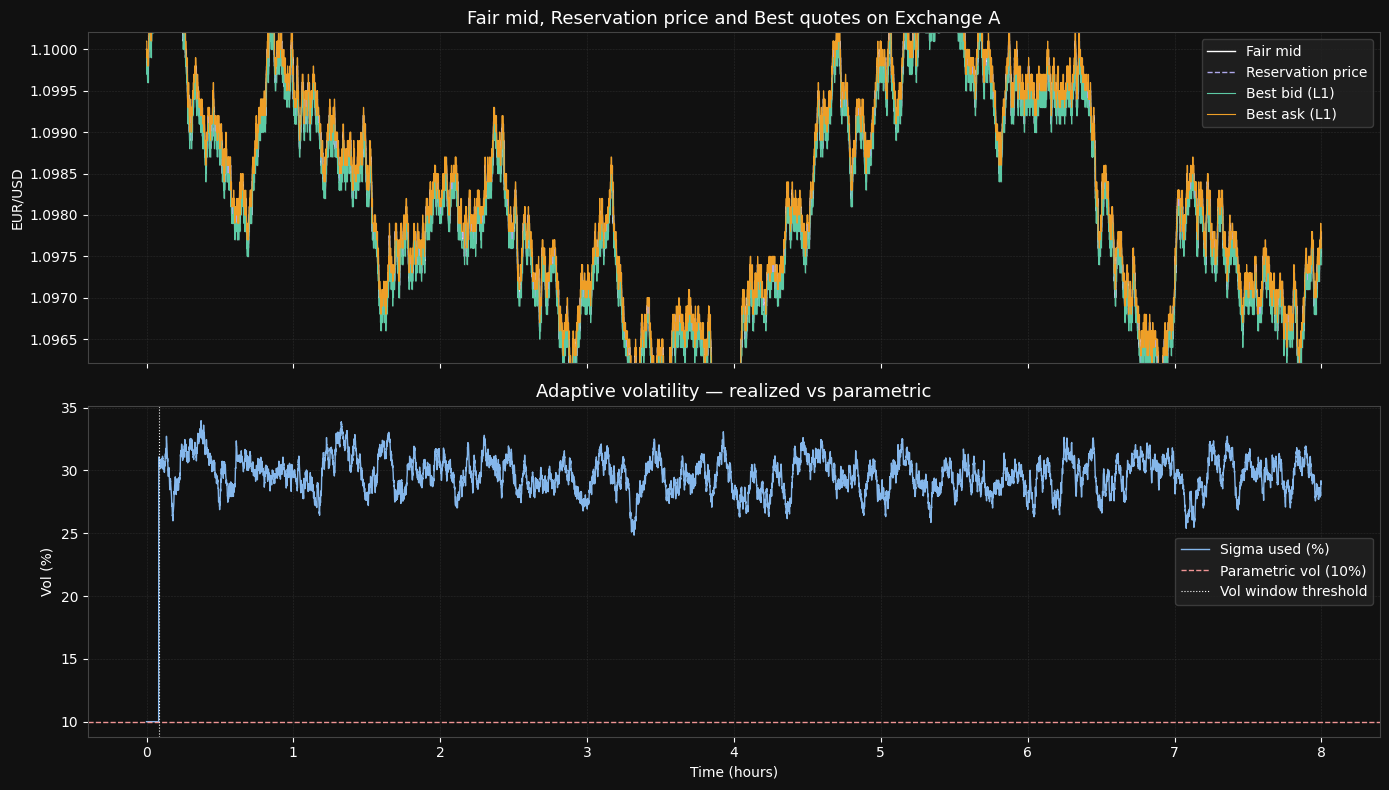

In [4]:
quoter2 = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)
snap_records = []
sample_every = 50

for step in range(0, stock.n_steps, sample_every):
    t = stock._time_grid[step]
    quotes, _ = quoter2.compute_quotes(step, t)
    quoter2.update_live_ids(list(range(step * 20, step * 20 + len(quotes))))
    snap = quoter2.snapshot(step, t)
    snap['t_hours'] = t / 3600
    snap_records.append(snap)

df2 = pd.DataFrame(snap_records)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#111111')

for ax in (ax1, ax2):
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, color='#444444')
    for spine in ax.spines.values(): spine.set_color('#444444')

# Top: prices
ax1.plot(df2['t_hours'], df2['fair_mid'],          color='#ffffff', linewidth=1.0, label='Fair mid')
ax1.plot(df2['t_hours'], df2['reservation_price'], color='#afa9ec', linewidth=1.0, linestyle='--', label='Reservation price')
ax1.plot(df2['t_hours'], df2['best_bid'],          color='#5dcaa5', linewidth=0.8, label='Best bid (L1)')
ax1.plot(df2['t_hours'], df2['best_ask'],          color='#ef9f27', linewidth=0.8, label='Best ask (L1)')
ax1.fill_between(df2['t_hours'], df2['best_bid'], df2['best_ask'], alpha=0.12, color='#ffffff')
mid_mean = df2['fair_mid'].mean()
ax1.set_ylim(mid_mean - 0.002, mid_mean + 0.002)
ax1.set_title('Fair mid, Reservation price and Best quotes on Exchange A', color='white', fontsize=13)
ax1.set_ylabel('EUR/USD', color='white')
ax1.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white')

# Bottom: realized vol vs parametric
ax2.plot(df2['t_hours'], df2['sigma_used'] * 100, color='#85b7eb', linewidth=1.0, label='Sigma used (%)')
ax2.axhline(stock.vol * 100, color='#f09595', linewidth=1.0, linestyle='--', label=f'Parametric vol ({stock.vol*100:.0f}%)')
ax2.axvline(cfg.vol_window * stock.time_step / 3600, color='#ffffff', linewidth=0.8, linestyle=':', label='Vol window threshold')
ax2.set_title('Adaptive volatility — realized vs parametric', color='white', fontsize=13)
ax2.set_xlabel('Time (hours)', color='white')
ax2.set_ylabel('Vol (%)', color='white')
ax2.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white')

plt.tight_layout()
plt.show()

## 4. Full 10-level book snapshot at midday — skewed sizing visible

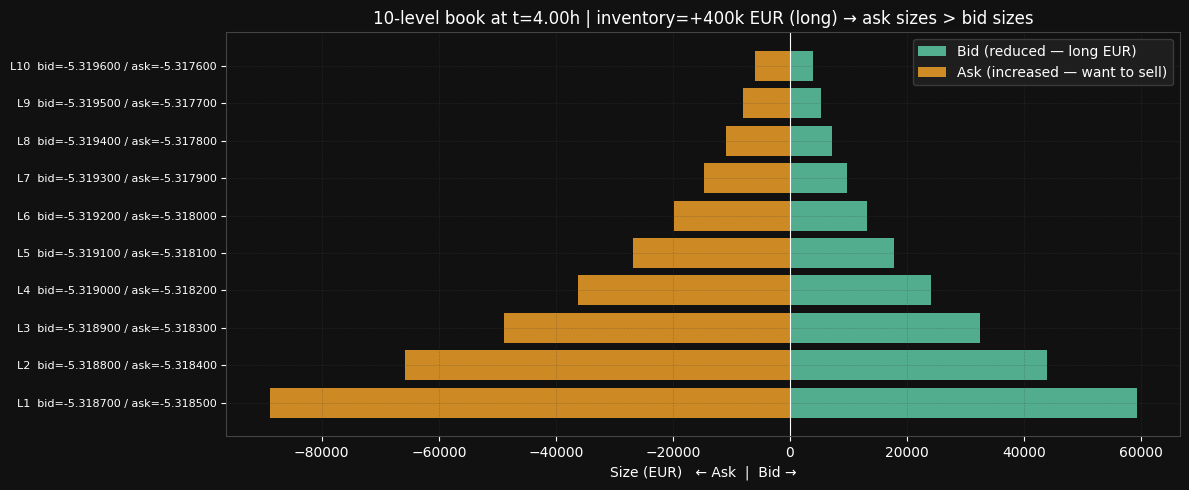

In [5]:
# Simulate a long inventory position to show skew effect
quoter3 = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)
quoter3.update_inventory(400_000.0)  # long 400k EUR → book should skew toward selling

midday_step = stock.n_steps // 2
t_mid = stock._time_grid[midday_step]
quotes, _ = quoter3.compute_quotes(midday_step, t_mid)

bids = sorted([q for q in quotes if q.direction == 'buy'],  key=lambda x: x.level)
asks = sorted([q for q in quotes if q.direction == 'sell'], key=lambda x: x.level)

bid_prices = [q.price for q in bids]
ask_prices = [q.price for q in asks]
bid_sizes  = [q.size  for q in bids]
ask_sizes  = [q.size  for q in asks]
levels     = [f'L{q.level}' for q in bids]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')

y = range(10)
ax.barh(y, bid_sizes,               color='#5dcaa5', alpha=0.85, label='Bid (reduced — long EUR)')
ax.barh(y, [-s for s in ask_sizes], color='#ef9f27', alpha=0.85, label='Ask (increased — want to sell)')
ax.axvline(0, color='white', linewidth=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels([f'{lv}  bid={b:.6f} / ask={a:.6f}' for lv, b, a in zip(levels, bid_prices, ask_prices)],
                   color='white', fontsize=8)
ax.set_title(f'10-level book at t={t_mid/3600:.2f}h | inventory=+400k EUR (long) → ask sizes > bid sizes', color='white', fontsize=12)
ax.set_xlabel('Size (EUR)   ← Ask  |  Bid →', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#222222', edgecolor='#444444', labelcolor='white')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4, color='#444444')
for spine in ax.spines.values(): spine.set_color('#444444')
plt.tight_layout()
plt.show()

## 5. Dynamic hedge routing — fee + depth aware

In [6]:
quoter4 = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)
quoter4.update_inventory(950_000.0)  # breach 90% delta limit

fair_mid = 1.10

# Scenario 1: normal — B has more depth
depth_B, depth_C = 5_000_000.0, 1_000_000.0
sB, sC, cost = quoter4.hedge_order(depth_B, depth_C, fair_mid)
print(f'Scenario 1 — B deep, C shallow:')
print(f'  Hedge on B: {sB:,.0f} EUR | Hedge on C: {sC:,.0f} EUR | Fee cost: {cost:.2f} EUR')
print(f'  Ratio B: {abs(sB)/(abs(sB)+abs(sC)):.1%}')

# Scenario 2: B is thin right now → C gets more
depth_B, depth_C = 200_000.0, 3_000_000.0
sB, sC, cost = quoter4.hedge_order(depth_B, depth_C, fair_mid)
print(f'\nScenario 2 — B shallow, C deep:')
print(f'  Hedge on B: {sB:,.0f} EUR | Hedge on C: {sC:,.0f} EUR | Fee cost: {cost:.2f} EUR')
print(f'  Ratio B: {abs(sB)/(abs(sB)+abs(sC)):.1%}')

# Scenario 3: B has zero depth (crashed)
depth_B, depth_C = 0.0, 2_000_000.0
sB, sC, cost = quoter4.hedge_order(depth_B, depth_C, fair_mid)
print(f'\nScenario 3 — B offline (depth=0):')
print(f'  Hedge on B: {sB:,.0f} EUR | Hedge on C: {sC:,.0f} EUR | Fee cost: {cost:.2f} EUR')
print(f'  Ratio B: {abs(sB)/(abs(sB)+abs(sC)):.1%} (all routed to C)')

# Fill cost on A
fill_size = 50_000.0
fc = quoter4.fill_cost(fill_size, fair_mid)
print(f'\nFill cost on A for {fill_size:,.0f} EUR fill: {fc:.2f} EUR ({cfg.fee_A_maker*100:.3f}% maker fee)')

Scenario 1 — B deep, C shallow:
  Hedge on B: -570,000 EUR | Hedge on C: -380,000 EUR | Fee cost: 250.80 EUR
  Ratio B: 60.0%

Scenario 2 — B shallow, C deep:
  Hedge on B: -569,999 EUR | Hedge on C: -380,001 EUR | Fee cost: 250.80 EUR
  Ratio B: 60.0%

Scenario 3 — B offline (depth=0):
  Hedge on B: -0 EUR | Hedge on C: -950,000 EUR | Fee cost: 313.50 EUR
  Ratio B: 0.0% (all routed to C)

Fill cost on A for 50,000 EUR fill: 5.50 EUR (0.010% maker fee)
